# VAE on MNIST\n\n**Objective:** build and train a small Variational Autoencoder (VAE) that learns to compress MNIST digits into a low-dimensional latent space and reconstruct them back, and use that same latent space to generate brand-new digit images by sampling random latent vectors.\n\nPipeline: `image -> encoder -> (mu, logvar) -> reparameterization -> z -> decoder -> reconstruction`

## Setup

Importing the `vae` module we already built (`model.py`, `dataset.py`) so this notebook doesn't duplicate that code.

In [1]:
import sys
from pathlib import Path

import torch
import matplotlib.pyplot as plt
from torchvision.utils import make_grid

# so we can import from the vae/ folder next to notebooks/
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT / "vae"))

from model import VAE, vae_loss
from dataset import get_dataloaders

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cpu


## Dataset

MNIST, downloaded into `../data`. Pixels are normalized to [0, 1] (just `ToTensor()`, no extra standardization) since the decoder ends in a sigmoid.

train batches: 469  test batches: 79


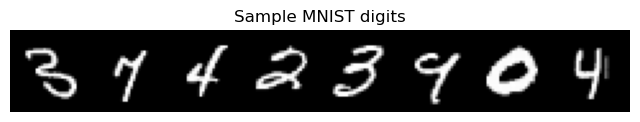

In [2]:
train_loader, test_loader = get_dataloaders(batch_size=128, data_dir=PROJECT_ROOT / "data")

print("train batches:", len(train_loader), " test batches:", len(test_loader))

# peek at a few training images
images, labels = next(iter(train_loader))
grid = make_grid(images[:8], nrow=8)

plt.figure(figsize=(8, 1.5))
plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
plt.axis("off")
plt.title("Sample MNIST digits")
plt.show()

## Model architecture

- **Encoder:** 2 conv layers (28x28 -> 7x7), flattened, then two linear heads producing `mu` and `logvar` (each a vector of size `latent_dim`).
- **Reparameterization:** `z = mu + eps * std`, `eps ~ N(0,1)`. This is what lets gradients flow through a "random" sampling step.
- **Decoder:** mirror of the encoder — linear layer back to 7x7, then 2 transposed conv layers up to 28x28, sigmoid output.

Loss = reconstruction loss (BCE) + KL divergence (pulls `q(z|x)` towards `N(0,1)`). Full code with comments is in `../vae/model.py`.

In [3]:
latent_dim = 20
model = VAE(latent_dim=latent_dim).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"\ntotal parameters: {n_params:,}")

VAE(
  (encoder_conv): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
  )
  (fc_mu): Linear(in_features=3136, out_features=20, bias=True)
  (fc_logvar): Linear(in_features=3136, out_features=20, bias=True)
  (decoder_fc): Linear(in_features=20, out_features=3136, bias=True)
  (decoder_conv): Sequential(
    (0): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(32, 1, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (3): Sigmoid()
  )
)

total parameters: 228,905


## Training

Just 3 epochs here to keep this notebook quick to run — this is meant to demonstrate the pipeline, not be the final trained model (that's what `python vae/train.py --epochs 15` is for, saved separately to `models/vae/vae.pt`).

In [4]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
n_epochs = 3

history = {"total": [], "recon": [], "kl": []}

for epoch in range(1, n_epochs + 1):
    model.train()
    total_sum, recon_sum, kl_sum = 0.0, 0.0, 0.0

    for images, _labels in train_loader:
        images = images.to(device)

        optimizer.zero_grad()
        recon, mu, logvar = model(images)
        loss, recon_loss, kl_loss = vae_loss(recon, images, mu, logvar)
        loss.backward()
        optimizer.step()

        total_sum += loss.item()
        recon_sum += recon_loss.item()
        kl_sum += kl_loss.item()

    n_batches = len(train_loader)
    history["total"].append(total_sum / n_batches)
    history["recon"].append(recon_sum / n_batches)
    history["kl"].append(kl_sum / n_batches)

    print(f"epoch {epoch}/{n_epochs} - total: {history['total'][-1]:.4f}  "
          f"recon: {history['recon'][-1]:.4f}  kl: {history['kl'][-1]:.4f}")

epoch 1/3 - total: 165.3083  recon: 141.0275  kl: 24.2808


epoch 2/3 - total: 120.4096  recon: 93.2392  kl: 27.1705


epoch 3/3 - total: 114.7634  recon: 87.7203  kl: 27.0431


## Training loss

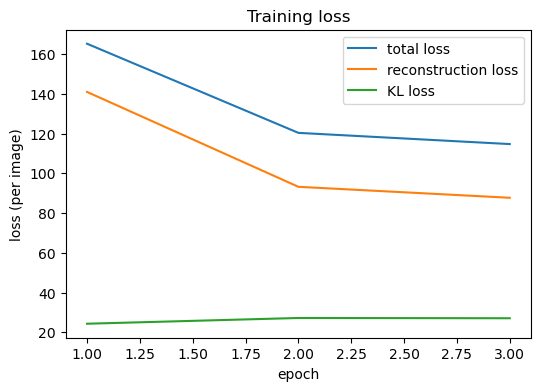

In [5]:
epochs = range(1, n_epochs + 1)

plt.figure(figsize=(6, 4))
plt.plot(epochs, history["total"], label="total loss")
plt.plot(epochs, history["recon"], label="reconstruction loss")
plt.plot(epochs, history["kl"], label="KL loss")
plt.xlabel("epoch")
plt.ylabel("loss (per image)")
plt.title("Training loss")
plt.legend()
plt.show()

## Original vs reconstruction

Top row: real test digits. Bottom row: what the VAE reconstructs after encoding + decoding them.

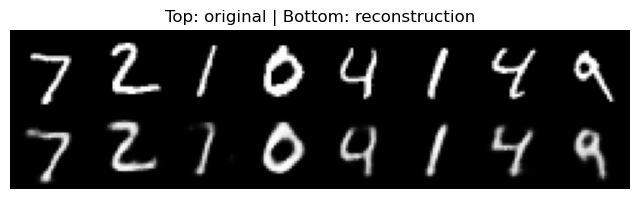

In [6]:
model.eval()

test_images, _ = next(iter(test_loader))
test_images = test_images[:8].to(device)

with torch.no_grad():
    recon, _mu, _logvar = model(test_images)

comparison = torch.cat([test_images.cpu(), recon.cpu()])
grid = make_grid(comparison, nrow=8)

plt.figure(figsize=(8, 2.5))
plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
plt.axis("off")
plt.title("Top: original | Bottom: reconstruction")
plt.show()

## Random samples from the latent space

This is the fun part — we skip the encoder entirely and just decode random vectors sampled from `N(0,1)`. If the KL term did its job, these should look like plausible (if a bit blurry) digits.

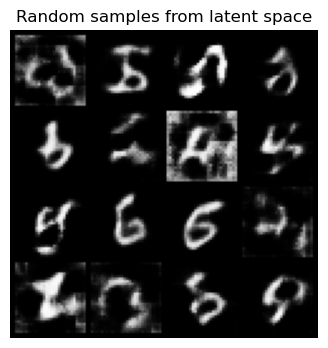

In [7]:
with torch.no_grad():
    z = torch.randn(16, latent_dim).to(device)
    samples = model.decode(z).cpu()

grid = make_grid(samples, nrow=4)
plt.figure(figsize=(4, 4))
plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
plt.axis("off")
plt.title("Random samples from latent space")
plt.show()

## Observations

- Reconstructions are a bit blurry, which is expected — this is a known VAE trait, the KL term trades off some sharpness for a well-organized latent space.
- Random samples already look digit-like after just 3 epochs, even though a decent chunk of them land between two digit shapes (e.g. something between a 4 and a 9). More epochs / a bigger latent dim would sharpen this up (see the full run via `vae/train.py`).
- This model only ever saw MNIST digits, so it can't reconstruct arbitrary photos — feeding it something else just gives back a blurry digit-shaped blob.